In [1]:
from src.gaussian_mixture import GaussianMixtureMAR
from src.dg import DataGenerator
from src.utils import true_quantile

import numpy as np
import matplotlib.pyplot as plt
import os

from joblib import Parallel, delayed

In [2]:
def quantile_x1(model, p, n_samples):
    x = model.sample(n_samples)[0]
    x1 = x[:, 0]
    q = np.quantile(x1, p)
    return q

# Parallel
def worker(delta):
    dg = DataGenerator(distr=dist, alpha=alpha, delta=delta)
    X, M = dg.generate(N, d)
    gmm.fit(X, M)
    return quantile_x1(gmm, p, n_samples)

In [3]:
# global parameters
N = 5000
n_samples = 5000
d = 3
cov_type = 'diag'
k_range = (1,20)
p = 0.1

B = 50

gmm = GaussianMixtureMAR(
    k_range=k_range,
    criterion='aic',
    device='cpu',
    cov_type=cov_type,
    n_init=20
    )

Normal with 
$$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

In [4]:
# param_vals
dist = 'Normal'
alpha = 0.7

deltas = [round(0.01*x,2) for x in range(1, 11)]

In [5]:
res = Parallel(n_jobs=15)(
        delayed(worker)(delta) 
        for delta in deltas
        for _ in range(B)
    )

  k=8 -> score=38295.0703
  k=8 -> score=38176.9727
  k=8 -> score=38277.4727
  k=8 -> score=38345.9414
  k=8 -> score=38278.2188
  k=8 -> score=38240.9531
  k=8 -> score=37909.9688
  k=8 -> score=38139.7500
  k=8 -> score=38276.0586
  k=8 -> score=38232.8672
  k=8 -> score=38207.0859
  k=8 -> score=38025.3555
  k=8 -> score=37877.9375
  k=8 -> score=38218.6641
  k=8 -> score=38250.3359
  k=13 -> score=38298.1562
  k=13 -> score=38199.4609
  k=13 -> score=38340.6250
  k=13 -> score=38272.3086
  k=13 -> score=38358.7422
  k=13 -> score=38314.0430
  k=13 -> score=38240.0820
  k=13 -> score=38171.0820
  k=13 -> score=38312.8438
  k=13 -> score=38043.9922
  k=13 -> score=37939.3672
  k=13 -> score=38262.5430
  k=13 -> score=38283.9727
  k=13 -> score=37912.2266
  k=13 -> score=38251.6875
  k=6 -> score=38289.7422
  k=6 -> score=38267.9531
  k=6 -> score=38180.9453
  k=6 -> score=38224.9141
  k=6 -> score=38331.9062
  k=6 -> score=38199.0820
  k=6 -> score=38265.5938
  k=6 -> score=38261.93

In [6]:
res = np.array(res)
res = res.reshape((len(deltas),-1))

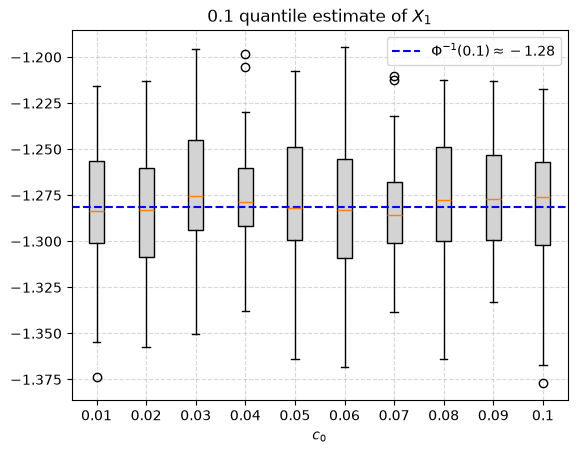

In [7]:
bp = plt.boxplot(res.T, tick_labels=deltas, patch_artist=True, widths=0.3)

# Color the box
for box in bp['boxes']:
    box.set_facecolor('lightgrey')

plt.axhline(
    y=true_quantile(dist), 
    color='blue', 
    linestyle='--', 
    label=r'$\Phi^{-1}(0.1) \approx -1.28$'
    )
plt.title(r"0.1 quantile estimate of $X_1$")
plt.xlabel(r'$c_0$')
plt.legend()
plt.grid(
    True,
    linestyle='--',
    alpha=0.5
    )
plt.savefig(
        os.path.join("results/figs", 'quantile_x1'),
        dpi=300,
        bbox_inches="tight"
    )
plt.show()